In [1]:
# 데이터 구성 패키지: Series, DataFrame
import pandas as pd
# 행렬 연산 패키지
import numpy as np

# 데이터 시각화 패키지
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# 가설검정 및 통계 분석 패키지
import scipy.stats as stats
from statsmodels.formula.api import ols

# 그래프 표시
%matplotlib inline

In [2]:
# 한글 폰트(맑은 고딕) 적용 : 윈도우, 구글 콜랩
matplotlib.rc('font', family='Malgun Gothic')
# 음수 표시
matplotlib.rc('axes', unicode_minus = False)

In [3]:
# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

# 3.연습

In [4]:
# df를 직접 입력 
df = pd.DataFrame({'satisfaction': [74.5, 81.2, 73.8, 82.0, 76.3, 75.7, 80.2, 72.6, 
                                    77.9, 82.8]})
df.head()

,satisfaction
0,74.5
1,81.2
2,73.8
3,82.0
4,76.3


In [5]:
df.mean()

satisfaction    77.7
dtype: float64

1점 올랐느느데 귀무가설을 시킬 수 없잖아
귀무가설 : 고객만족도라는 76.7이랑 같다
뭐더라 : 고객만족도라는 76.7이랑 다르다

t검정 하려면 정규성 검증해야함

<Axes: >

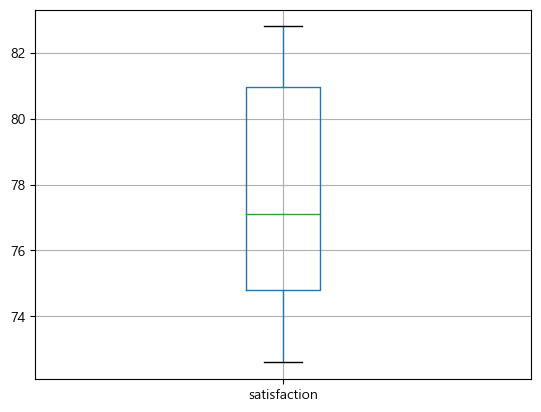

In [6]:
# boxplot
# 걍 그려봄
df.boxplot()

In [7]:
# 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df)
print("statistic={}, p-value={}".format(statistic, p))

statistic=0.9331595173803356, p-value=0.47967864458004233


p 값만 보면 돼 0.5이상이여야
되니까 원셈플 할거임

In [8]:
# 1-Sample t-test
t_result = stats.ttest_1samp(df, 76.7)  # , 타겟(평균)

# t값, p값 
t, p = t_result.statistic, t_result.pvalue

In [9]:
# 1-Sample t-test의 t값 p값 출력
print( " 1-Sample t-test ")
print( "  t검정 통계량 : {} " .format(t)) ; print( "  p-value : {} " .format(p))

 1-Sample t-test 
  t검정 통계량 : [0.86437028] 
  p-value : [0.40983028] 


기각 시킬 수 없다.. !! 0.05 보다 크다 유의 수준보다 크기 때문에 ㅇ없음!!!  

P-value < 0.05 $\rightarrow$ 귀무가설 '탈락'(기각) $\rightarrow$ 새로운 사실 발견!

# 4. 연습


서로 다른 두 집단 간에!!!

In [10]:
# 데이터 가져오기 ( data set : 2sample.csv ) 
# Data직접 입력 
df = pd.DataFrame({'A': [6, 5, 5, 4, 6, 7, 6, 4, 5, 6, 4, 5, 5, 6, 4, 8, 6, 5, 6, 7], 
                   'B': [7, 6, 7, 8, 7, 8, 8, 5, 7, 6, 5, 5, 6, 6, 5, 7, 9, 7, 7, 8]})
df.head()

,A,B
0,6,7
1,5,6
2,5,7
3,4,8
4,6,7


In [11]:
df.mean()

A    5.5
B    6.7
dtype: float64

<Axes: >

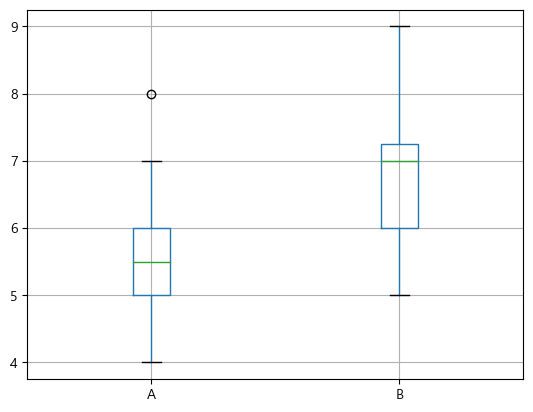

In [12]:
# Group별 boxplot
df.boxplot()

귀무가설 : 고객 평가 평균 점수가 같다  

대립가설 : 다르다  

전제 조건 : A 집단, B 집단 각각 정규성 검증  
        : 등분산성 검증 해야한다.

In [13]:
#'cust A' 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df['A'])

In [14]:
print("statistic={}, p-value={}".format(statistic,p))

statistic=0.9094843757142952, p-value=0.06231014582345956


In [15]:
#'cust B' 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df['B'])

In [16]:
print("statistic={}, p-value={}".format(statistic, p))

statistic=0.9142492813717525, p-value=0.07683589072502073


0.05보다 크다 둘 다 p 값이 -> 정규분포를 따른다!!

In [17]:
# equal variance test 
stats.bartlett(df['A'], df['B'])

BartlettResult(statistic=0.6667459069073581, pvalue=0.41418843768748703)

※ p-value가 0.54이므로, 두 집단의 분산은 같다고 할 수 있다

정규서이랑 등분이랑 둘 다니까 그 뭐야 웰치스 안가도 됨

In [18]:
# 2-Sample t-test
t_result = stats.ttest_ind(df['A'], df['B'], equal_var = True)

# t값,  p값  
t, p = t_result.statistic, t_result.pvalue

In [19]:
# 2-Sample t-test의 t값 p값 출력
print( " 2-Sample t-test ")
print( "  t검정통계량: {} " .format(t)) ; print( " p-value : {} " .format(p))

 2-Sample t-test 
  t검정통계량: -3.3349589531975052 
 p-value : 0.0019136289265287215 


t가 마이너스면 : 평균이 a가 더 높게 나온대!!

※ 결론 : 유의수준 5%에서 검정결과 P값이 0.001 이므로 고객간에 고객만족도의 차이가 있다 

# 5 연습


집단 하나에 대해서 처치만 다른거!!! 대표적인 페어드 티!!

귀무가설 : 후와 전이 같더라 

In [20]:
# df1, df2를 직접 입력 
df1 = pd.DataFrame({'before': [720, 589, 780, 648, 720, 589, 780, 648, 780, 648]})
df2 = pd.DataFrame({'after': [810, 670, 790, 712, 810, 670, 790, 712, 790, 712]})

In [21]:
# Paired t-test
t_result = stats.ttest_rel(df1['before'], df2['after'])

# t값, p값 
t, p = t_result.statistic, t_result.pvalue

In [22]:
# Paired t-test의 t값 p값 출력
print( "Paired t-test ")
print( " t: {} " .format(t))
print( " p: {} " .format(p))

Paired t-test 
 t: -5.3239144979574125 
 p: 0.00047850760899337117 


유의수준인 5퍼 보다 낮은 0.0이니까, 귀무가설 기각!!
앞에서 뒤를 빼는거래 그래서 t가 - 마이너스면 학ㅇ원을 간 차이가 있다는 것!!

# 6 연스   

In [23]:
# proportion test 패키지
from statsmodels.stats.proportion import proportions_ztest

In [24]:
# 가설 설정
# Ho : p =  0.1
# H1 : p ≠ 0.1      * p^ = x/n = 15/100= 0.15

# 변수 선언 
count = 15
n_obs = 100
value = 0.1

# Proportion test 실행
statistic, p = proportions_ztest(count, n_obs, value)

In [25]:
# Proportion test 결과 출력
print( "1 Proportion test")
print( ' z: {0:0.3f}' .format(statistic))
print( ' p: {0:0.3f}'.format(p))

1 Proportion test
 z: 1.400
 p: 0.161


16프로네 귀무가설 기각하면 안된다.'

※ 결론 : 결과적으로 고급강 A제품에 대해 품질개선 결과 기존 대비 사용비율이 차이가 있다고 할 수 없다.

품질만ㄷ족도가 올랐다고 할수 없다....

### 어케하는거임?

In [26]:
# Proportion test 결과 출력
print( "1 Proportion test")
print( ' z: {0:0.3f}' .format(statistic))
print( ' p: {0:0.3f}'.format(p))

1 Proportion test
 z: 1.400
 p: 0.161


In [27]:
# 가설 설정
# Ho : p =  0.1
# H1 : p ≠ 0.1      * p^ = x/n = 15/100= 0.15

# 변수 선언 
count = 15
n_obs = 100
value = 0.1

# Proportion test 실행
p = stats.binomtest(count, n_obs, value)

# 7 연습


문제 상황 : 

In [28]:
# 변수 선언 : 불량수
count = np.array([4, 1])
print(count)

[4 1]


In [29]:
# 변수 선언 : 관측치
n_obs = np.array([1000, 1200])
print(n_obs)

[1000 1200]


In [30]:
# Proportion test 실행
stat, p = proportions_ztest(count, n_obs)

In [31]:
# Proportion test 결과 출력
print("2 Proportion test ")
print('z검정통계량:{0:0.3f}'.format(stat)) ; print('p-value:{0:0.3f}'.format(p))

2 Proportion test 
z검정통계량:1.553
p-value:0.120


헉 12프로다 귀무가설을 기각할 수 없다. 차이가 없다는거다!, 통계적으로 유의미한 차이가 없다.

### 8. 연습 (카이제곱 검정, chi-square test) 
   - 근무조별로 철강제품을 생산하고 있는데, 생산 제품의 규격이 3가지 종류가 있다.근무조별로 제품을 생산하는 부하는 차이가 있겠는가? (유의수준 0.05)

In [32]:
# df 생성  
df = pd.DataFrame({'Work_1':[270, 228, 277], 'Work_2':[260, 285, 284],
                   'Work_3':[236, 225, 231], 'Work_4':[234, 262, 208]})

df.head()

,Work_1,Work_2,Work_3,Work_4
0,270,260,236,234
1,228,285,225,262
2,277,284,231,208


In [33]:
# from scipy.stats import chi2_contingency

In [34]:
# chi-square test 실행
chi, pval, dof, expected = stats.chi2_contingency(df)
chi, pval, dof, expected

(13.36627391246374,
 0.03757449387917437,
 6,
 array([[258.33333333, 276.33333333, 230.66666667, 234.66666667],
        [258.33333333, 276.33333333, 230.66666667, 234.66666667],
        [258.33333333, 276.33333333, 230.66666667, 234.66666667]]))

In [35]:
# chi-square test 결과 출력
print( "chi-square test ")
print( ' chisq: {0:0.2f}' .format(chi))
print( ' p-value : {0:0.3f}'.format(pval))
print( ' degree of freedom: {}' .format(dof))
print( ' expected value: \n{}' .format(expected.round(1)))

chi-square test 
 chisq: 13.37
 p-value : 0.038
 degree of freedom: 6
 expected value: 
[[258.3 276.3 230.7 234.7]
 [258.3 276.3 230.7 234.7]
 [258.3 276.3 230.7 234.7]]


### 9. 연습 (ANOVA) 
  - OO회사  마케팅실  그룹별 직원들의 TOEIC 성적에 차이가 있는지를 알고 싶다.
  - A Group, B Group, C Group 간의 토익 점수의 차이 여부를 검정하여라. (유의수준(a)=0.05)

In [36]:
# df 입력
df = pd.DataFrame({'A': [892, 623, 721, 678, 723, 790, 720, 670, 690, 771],
                   'B': [721, 821, 910, 678, 723, 790, 711, 790, 745, 891],
                   'C': [760, 915, 888, 721, 894, 834, 841, 912, 845, 889]})
df.head()

,A,B,C
0,892,721,760
1,623,821,915
2,721,910,888
3,678,678,721
4,723,723,894


<Axes: >

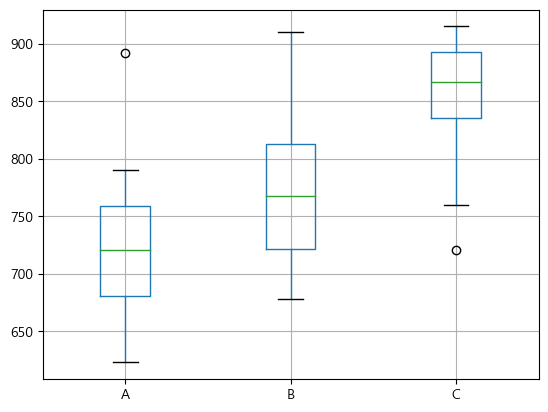

In [37]:
# Group별 boxplot
df.boxplot(['A', 'B', 'C'])

정규성 검정은 각각 해야해

In [38]:
# 'A' 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df['A'])
print("statistic={}, p-value={}".format(statistic,p))

statistic=0.9293239820027549, p-value=0.4412758324604767


In [39]:
# 'B' 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df['B'])
print("statistic={}, p-value={}".format(statistic,p))

statistic=0.9242647283417711, p-value=0.39390041877643295


In [40]:
# 'C' 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df['C'])
print("statistic={}, p-value={}".format(statistic,p))

statistic=0.8679398859067827, p-value=0.09458102900458963


0.005보다 다 크다 귀무가설을 기각하지 못함 $\rightarrow$ 정규성 통과(만족)!

In [41]:
# from scipy.stats import bartlett
stats.bartlett(df['A'], df['B'], df['C'])

BartlettResult(statistic=1.5874344648422165, pvalue=0.4521608803857069)

: $0.452 > 0.05$이므로 귀무가설(세 집단의 분산이 같다)을 기각하지 못합니다.  
ANOVA 분석해도 된다.

In [42]:
# ANOVA 실행
f_result = stats.f_oneway(df['A'], df['B'], df['C'])

# ANOVA의 f값 p값 저장 
f, p = f_result.statistic, f_result.pvalue

In [43]:
# ANOVA의 f값, p값 출력
print( "One-way ANOVA ")
print( " F통계량 : {} " .format(f))
print( " p-value : {} " .format(p))

One-way ANOVA 
 F통계량 : 7.09567210575343 
 p-value : 0.0033383379006591118 


※ 유의수준 0.05 에서 p-value가 0.003 이므로 마케팅실 그룹별 직원들의 TOEIC 성적에 차이가 있다고 할 수 있다 

p 값이 작다 기각 하자! 차이가 있다고 할 수 있다. 오류가 날 확률이 적다.

확률이 적네 그럼 두개씩 한 번 해볼까? 요렇게 생각해볼 수 잇다.

### 10.연습(ANOVA)

In [44]:
# df 생성  
df1 = [1, 2, 3, 4, 4, 5, 6, 6, 7, 8]
df2 = [23, 29, 49, 64, 74, 87, 96, 97, 109, 119]

In [45]:
# Correlation Analysis 실행
corr, pval = stats.pearsonr(df1, df2)

In [46]:
# Correlation, p-value 결과 출력 
print( "Correlation Analysis ")
print( ' corr: {0:0.3f}' .format(corr))
print( ' p-value : {0:0.3f}'.format(pval))

Correlation Analysis 
 corr: 0.989
 p-value : 0.000


p값이 0이네 그럼 귀문가설을 강력하게 기각을 할 수 있다는 것이다 왜냐면 오류가 날 가능성이 아예 없기 때문이다.   
귀문가설은 두 집단이 상관이 없다라는 것이였다  
그럼 기각을 할 수 있다는 것이니 

상관의 크기가 r에 영향이 미침 : 0.989 정도

relation : 관계의 크기를 보여줌